In [16]:
import warnings
warnings.filterwarnings("ignore")

import time
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [17]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

X_train_scaled = joblib.load("../data/processed/X_train_scaled.pkl")
X_test_scaled = joblib.load("../data/processed/X_test_scaled.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [18]:
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),

    "LightGBM":
        LGBMClassifier(
            random_state=42
        ),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )

}

In [19]:
results = []

best_model = None
best_f1 = 0

def evaluate(model_name, model):

    global best_model
    global best_f1

    if model_name == "Logistic Regression":

        train_data = X_train_scaled
        test_data = X_test_scaled

    else:

        train_data = X_train
        test_data = X_test

    start = time.time()

    model.fit(train_data, y_train)

    train_time = time.time() - start

    start = time.time()

    pred = model.predict(test_data)

    predict_time = time.time() - start

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(test_data)[:,1]
    else:
        prob = pred

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    results.append({

        "Model":model_name,
        "Accuracy":accuracy,
        "Precision":precision,
        "Recall":recall,
        "F1":f1,
        "ROC":roc,
        "Train Time":train_time,
        "Predict Time":predict_time

    })

    if f1 > best_f1:

        best_f1 = f1
        best_model = model

    print(f"{model_name} completed.")

In [20]:
for name, model in models.items():

    evaluate(name, model)

Logistic Regression completed.
Decision Tree completed.
Random Forest completed.
XGBoost completed.


Exception in thread Thread-50 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 73: character maps to <undefined>


[LightGBM] [Info] Number of positive: 7623, number of negative: 23385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5668
[LightGBM] [Info] Number of data points in the train set: 31008, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.245840 -> initscore=-1.120925
[LightGBM] [Info] Start training from score -1.120925
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM completed.
CatBoost completed.


In [21]:
results = pd.DataFrame(results)

results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC,Train Time,Predict Time
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000,0.225311,0.002013
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,1.393251,0.116567
4,LightGBM,1.000000,1.000000,1.000000,1.000000,1.000000,3.535729,0.032531
3,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000,1.324718,0.004397
5,CatBoost,1.000000,1.000000,1.000000,1.000000,1.000000,10.712531,0.008195
1,Decision Tree,0.999742,0.999475,0.999475,0.999475,0.999652,0.276512,0.002152


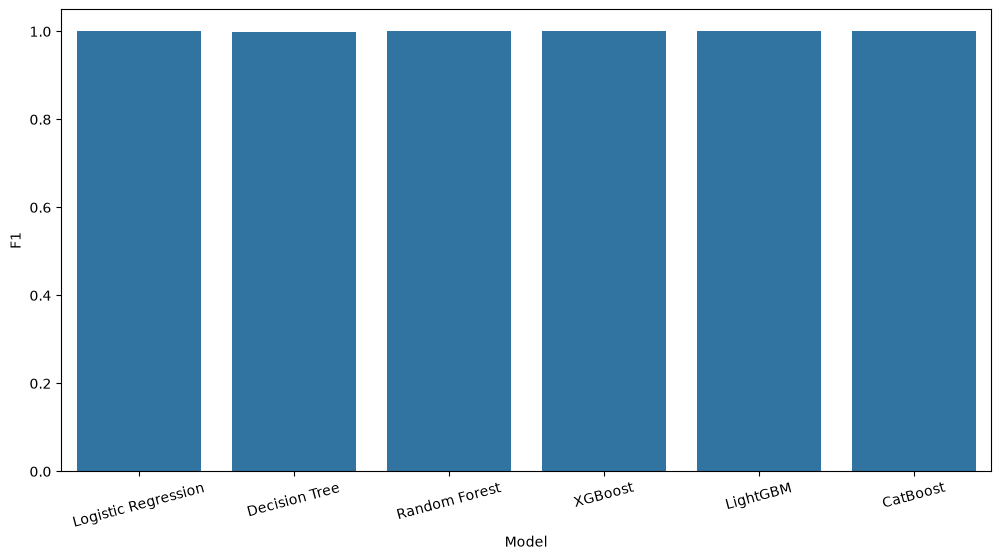

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results,
    x="Model",
    y="F1"
)

plt.xticks(rotation=15)

plt.show()

In [23]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

print("Best Model Saved")

Best Model Saved
